# Linear and Multiple Regression

Program to implement linear and multiple regression techniques using a standard dataset available in the public domain and evaluate its performance.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = datasets.load_diabetes()
df['feature_names']

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

## Load the Diabetes Dataset

In [4]:
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)
diabetes_X.shape

(442, 10)

In [5]:
diabetes_y.shape

(442,)

## Linear Regression

Use only one feature from the diabetes dataset for linear regression.

In [6]:
diabetes_X = diabetes_X[:, np.newaxis, 2]
diabetes_X.shape

(442, 1)

## Split the Data into Training and Testing Sets

In [8]:
diabetes_X_train = diabetes_X[:-20]
diabetes_X_test = diabetes_X[-20:]

diabetes_y_train = diabetes_y[:-20]
diabetes_y_test = diabetes_y[-20:]

## Create the Linear Regression Model

In [9]:
regr = linear_model.LinearRegression()

## Train the Model

In [10]:
regr.fit(diabetes_X_train, diabetes_y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[938.24]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,152.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[0.98]


## Make Predictions Using the Testing Set

In [11]:
diabetes_y_pred = regr.predict(diabetes_X_test)

## Evaluate the Linear Regression Model

In [12]:
print("Coefficients: \n", regr.coef_)

print("Mean squared error: %.2f"
      % mean_squared_error(diabetes_y_test, diabetes_y_pred))

print("Coefficient of determination: %.2f"
      % r2_score(diabetes_y_test, diabetes_y_pred))

Coefficients: 
 [938.23786125]
Mean squared error: 2548.07
Coefficient of determination: 0.47


## Plot the Linear Regression Results

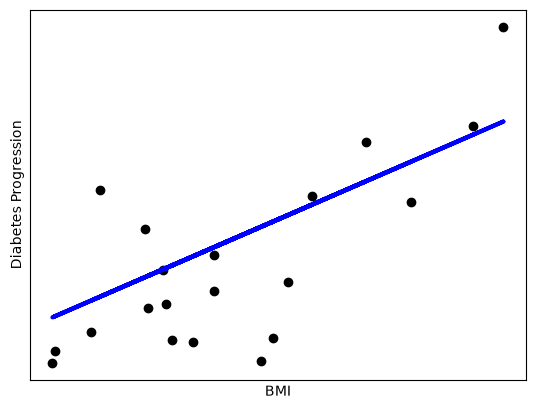

In [13]:
plt.scatter(diabetes_X_test, diabetes_y_test, color="black")
plt.plot(diabetes_X_test, diabetes_y_pred, color="blue", linewidth=3)

plt.xlabel("BMI")
plt.ylabel("Diabetes Progression")

plt.xticks(())
plt.yticks(())

plt.show()

# Multiple Regression

Use multiple features from the diabetes dataset for multiple regression.

In [14]:
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)

diabetes_X.shape

(442, 10)

In [15]:
diabetes_X = diabetes_X[:, [0, 2]]
diabetes_X.shape

(442, 2)

## Split the Data into Training and Testing Sets

In [16]:
diabetes_X_train = diabetes_X[:-20]
diabetes_X_test = diabetes_X[-20:]

diabetes_y_train = diabetes_y[:-20]
diabetes_y_test = diabetes_y[-20:]

## Create and Train the Multiple Regression Model

In [17]:
regr = linear_model.LinearRegression()

regr.fit(diabetes_X_train, diabetes_y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[139.2 ,912.45]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,152.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[1.07,0.88]"


## Make Predictions

In [19]:
diabetes_y_pred = regr.predict(diabetes_X_test)

## Evaluate the Multiple Regression Model

In [20]:
print("Coefficients: \n", regr.coef_)
print("Intercept: \n", regr.intercept_)

print("Mean squared error: %.2f"
      % mean_squared_error(diabetes_y_test, diabetes_y_pred))

print("Coefficient of determination: %.2f"
      % r2_score(diabetes_y_test, diabetes_y_pred))

Coefficients: 
 [139.20420118 912.45355549]
Intercept: 
 152.87670001405584
Mean squared error: 2596.60
Coefficient of determination: 0.46


## Prepare Data for 3D Visualization

In [21]:
x = diabetes_X_test[:, 0]
y = diabetes_X_test[:, 1]

## Plot the Multiple Regression Results in 3D

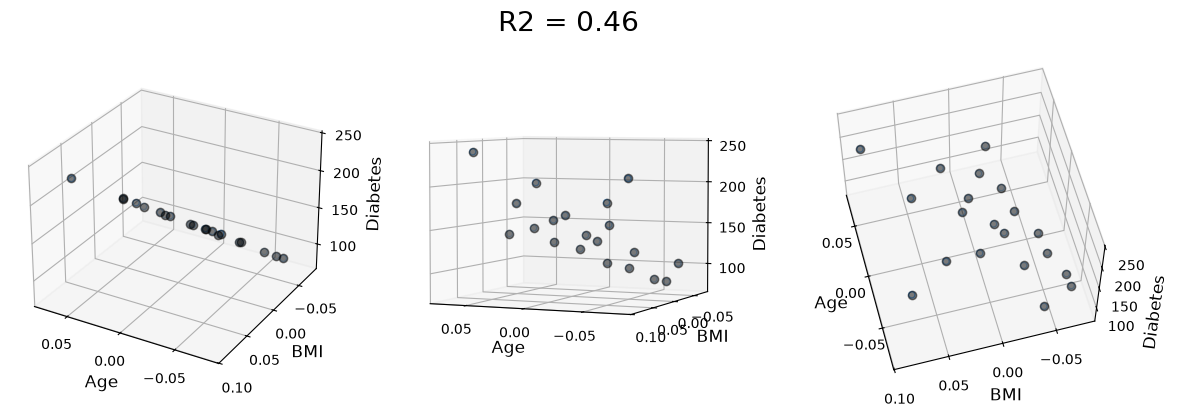

In [22]:
plt.style.use('default')

fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')

axes = [ax1, ax2, ax3]

for ax in axes:
    ax.plot(
        x, y, diabetes_y_pred,
        color='k',
        zorder=15,
        linestyle='none',
        marker='o',
        alpha=0.5
    )

    ax.scatter(
        x.flatten(),
        y.flatten(),
        diabetes_y_pred,
        facecolor=(0, 0, 0, 0),
        s=20,
        edgecolor='#70b3f0'
    )

    ax.set_xlabel('Age', fontsize=12)
    ax.set_ylabel('BMI', fontsize=12)
    ax.set_zlabel('Diabetes', fontsize=12)

    ax.locator_params(nbins=4, axis='x')
    ax.locator_params(nbins=5, axis='y')

ax1.view_init(elev=28, azim=120)
ax2.view_init(elev=4, azim=114)
ax3.view_init(elev=60, azim=165)

fig.suptitle(
    'R2 = %.2f' % r2_score(diabetes_y_test, diabetes_y_pred),
    fontsize=20
)

fig.tight_layout()
plt.show()